    What is Embeddings?
    Think of embeddings as a way to translate words into a language that computers can understand - numbers. Each word is represented as a vector, which is essentially a list of numbers. These vectors capture the meaning and relationships between words in a way that allows machines to process and analyze them effectively.
    For example, the word "king" might be represented as a vector like [0.5, 0.2, 0.1], while "queen" might be represented as [0.5, 0.2, 0.2]. The similarity between these vectors can help a machine understand that "king" and "queen" are related concepts.

Visualization of Embedding and Cosine Similarity

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# Simplified 20 example (real embeddings have hundreds of dimensions)
word_embeddings = {
    "cat": np.array([0.8, 0.6]),
    "kitten": np.array([0.75, 0.65]),
    "dog": np.array([0.7, 0.3]),
    "puppy": np.array([0.65, 0.35]),
    "car": np.array([-0.2, 0.9]),
    "truck": np.array([0.1, 0.95]),
    "apple": np.array([0.5, 0.8])
}

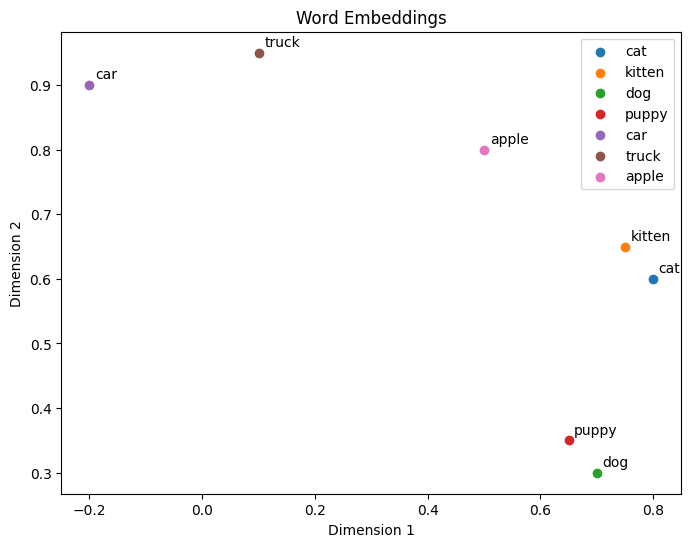

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

for word, coords in word_embeddings.items():
    ax.scatter(coords[0], coords[1], label=word)
    ax.text(coords[0] + 0.01, coords[1] + 0.01, word)

ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")
ax.set_title("Word Embeddings")
ax.legend()
plt.show()

In [15]:
# Measuring similarity using cosine similarity
def cosine_similarity(vec1, vec2):
    """
    Cosine similarity measures the cosine of the angle between two vectors, giving a value between -1 and 1.
    A value of 1 means the vectors are identical, 0 means they are orthogonal, and -1 means they are opposite.
    """
    dot_product = np.dot(vec1, vec2)
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)
    return dot_product / (norm_vec1 * norm_vec2)

In [16]:
print(f"Cosine Similarity between 'cat' and 'kitten': {cosine_similarity(word_embeddings['cat'], word_embeddings['kitten']):.4f}")
print(f"Cosine Similarity between 'cat' and 'dog': {cosine_similarity(word_embeddings['cat'], word_embeddings['dog']):.4f}")
print(f"Cosine Similarity between 'car' and 'apple': {cosine_similarity(word_embeddings['car'], word_embeddings['apple']):.4f}")

Cosine Similarity between 'cat' and 'kitten': 0.9975
Cosine Similarity between 'cat' and 'dog': 0.9717
Cosine Similarity between 'car' and 'apple': 0.7128


Creating your first Embeddings

In [ ]:
# HuggingFace and OPENAI Models
# HuggingFace contains a wide variety of models, including BERT, GPT-2, RoBERTa, and many more. These models can be used for various NLP tasks such as text classification, question answering, and language generation.
# OpenAI provides models like GPT-3, which is a powerful language model capable of generating human-like text, answering questions, and performing various language tasks. GPT-3 is known for its large size and versatility in handling a wide range of applications.

In [ ]:
from langchain_huggingface import HuggingFaceEmbeddings

# Initialize a simple Embedding model(no API key required)
embedding_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
print("Embedding Model:", embedding_model)

# Example usage
text = "Hello, how are you?"
embedding_vector = embedding_model.embed_query(text)
print(f"Embedding vector for '{text}': {embedding_vector[:5]}...")  # Print the first 5 dimensions for brevity
print(f"Embedding vector length: {len(embedding_vector)}")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4669.56it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding Model: model_name='sentence-transformers/all-MiniLM-L6-v2' cache_folder=None model_kwargs={} encode_kwargs={} query_encode_kwargs={} multi_process=False show_progress=False
Embedding vector for 'Hello, how are you?': [0.019096774980425835, 0.034465137869119644, 0.09162800759077072, 0.07016535103321075, -0.029946569353342056]...
Embedding vector length: 384


In [24]:
# Create a first embeddings
text = "Hello, I am learning about embeddings."

embedding_vector = embedding_model.embed_query(text)
print(f"Embedding vector for '{text}': {embedding_vector[:5]}...")

Embedding vector for 'Hello, I am learning about embeddings.': [-0.023014258593320847, -0.10264790803194046, -0.0001035052482620813, 0.003793425625190139, 0.015323200263082981]...


In [26]:
sentences = [
    "I love machine learning.",
    "The cat is on the roof.",
    "OpenAI develops powerful language models.",
    "The weather is nice today."
]
sentence_embeddings = embedding_model.embed_documents(sentences)
print("Sentence Embeddings:", sentence_embeddings[0]) 
print("Sentence Embeddings:", sentence_embeddings[1])

for sentence, embedding in zip(sentences, sentence_embeddings):
    print(f"Sentence: '{sentence}' - Embedding (first 5 dimensions): {embedding[:5]}...")


Sentence Embeddings: [-0.01685103215277195, -0.07072185724973679, 0.08554095029830933, -0.0017661103047430515, 0.04520879313349724, -0.05311217159032822, -0.048555273562669754, -0.03103921376168728, 0.019992012530565262, 0.0013778468128293753, -0.05642642825841904, 0.08474868535995483, 0.031358812004327774, -0.009936269372701645, -0.025161853060126305, 0.01564568653702736, -0.05058755725622177, 0.010036615654826164, -0.09949710965156555, -0.11036437749862671, -0.05488479882478714, 0.013054996728897095, 0.0016936952015385032, 0.0010150414891541004, 0.028596090152859688, 0.01457250863313675, 0.020524321123957634, -0.008306204341351986, -0.014727827161550522, -0.0560147687792778, -0.01239266898483038, 0.05011459439992905, 0.0008126295288093388, 0.03934530168771744, -0.08508958667516708, 0.021291326731443405, 0.01746697537600994, 0.03295697644352913, 0.01733020320534706, 0.0356920063495636, -0.026970818638801575, -0.00045756337931379676, 0.020498383790254593, 0.012121226638555527, 0.062343